[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    2.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    0.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elaps

0.7392290249433107
              precision    recall  f1-score   support

           0       0.93      0.75      0.83       370
           1       0.35      0.70      0.47        71

    accuracy                           0.74       441
   macro avg       0.64      0.73      0.65       441
weighted avg       0.84      0.74      0.77       441

0.757080319756376
9.399138638885425


[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    0.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


0.7735665694849369


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    0.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s


0.7392290249433107
[[276  94]
 [ 21  50]]


[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    0.2s finished


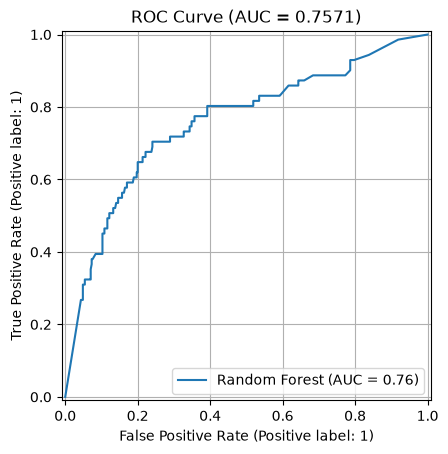

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  5.2min finished


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import logging

df = pd.read_csv("data/HR-Employee-Attrition.csv")

df_cat = df.select_dtypes(exclude = 'number').drop(['Attrition','Over18'],axis =1)
df_num = df.select_dtypes(include = 'number')

df_cat_onehot =['BusinessTravel', 'Department']
df_cat_ordinal =['Gender','OverTime']
df_cat_catencode = ['EducationField','JobRole','MaritalStatus']

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE 
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PowerTransformer
from category_encoders import CatBoostEncoder
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold, cross_validate,RepeatedStratifiedKFold
from sklearn.feature_selection import SelectKBest,mutual_info_classif
from sklearn.ensemble import RandomForestClassifier,StackingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

transform_cat_onehot  = Pipeline(steps =[('cat_onehot',OneHotEncoder(drop='first',handle_unknown='ignore'))])
tranform_cat_ordinal = Pipeline(steps =[('cat_ordinal',OrdinalEncoder(handle_unknown='error'))])
tranform_cat_catencode = Pipeline(steps=[('cat_catencode',CatBoostEncoder(handle_unknown='value',random_state=42,verbose=True))])
tranform_num = Pipeline(steps=[('num_powertranform', PowerTransformer(method='yeo-johnson'))])

preprocess = ColumnTransformer(transformers=[('num',tranform_num, df_num.columns.to_list()),
                                             ('cat_onehot_col',transform_cat_onehot,df_cat_onehot),
                                             ('cat_ordinal_col',tranform_cat_ordinal,df_cat_ordinal),
                                             ('cat_catencode_col',tranform_cat_catencode,df_cat_catencode)																																													
																																													],remainder='drop')

select_feature = SelectKBest(score_func=mutual_info_classif, k=23)


estimators = [('catboost',CatBoostClassifier(iterations=1000,auto_class_weights='Balanced',learning_rate=0.0001,depth=6,
                                              loss_function='Logloss',eval_metric='Accuracy',early_stopping_rounds=50
                                              ,od_type='Iter',verbose=True))]

final_estimator_RF = RandomForestClassifier(bootstrap=True,class_weight='balanced',criterion='gini',ccp_alpha=0.0001,
                                         n_estimators=1000,n_jobs=-1,verbose=True,random_state=42,oob_score=True,
                                         max_depth=10)


final_estimator=CatBoostClassifier(iterations=1000,auto_class_weights='Balanced',learning_rate=0.0001,depth=6,
                                              loss_function='Logloss',eval_metric='Accuracy',early_stopping_rounds=50
                                              ,od_type='Iter',verbose=True)

model_stack = StackingClassifier(estimators=estimators, final_estimator=final_estimator_RF,cv=10,n_jobs=-1,verbose=True)

model= Pipeline(steps=[('preprocess',preprocess),
                       ('SMOTEENN',SMOTEENN(random_state=42)),
                       ('select_feature',select_feature),
                       ('model_stack',model_stack)                       
                       ])
X= df[df_cat_onehot+df_cat_ordinal+df_cat_catencode+ df_num.columns.tolist()]

y = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0) # Encode target to 0 and 1



X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.30, random_state=42,stratify=y)


model.fit(X_train,y_train)

y_pred= model.predict(X_test)
y_pred_prob= model.predict_proba(X_test)[:,1]


from sklearn.metrics import accuracy_score,classification_report,roc_curve,roc_auc_score,log_loss,confusion_matrix
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(roc_auc_score(y_test,y_pred_prob))
print(log_loss(y_test,y_pred))
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))
print(confusion_matrix(y_test,y_pred))


import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Calculate the prediction probabilities for the test set
# Replace 'model', 'X_test', and 'y_test' with your actual variable names
y_probs = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

# Plot the curve
display = RocCurveDisplay.from_predictions(
    y_test, y_probs, name="Random Forest"
)
plt.title(f"ROC Curve (AUC = {auc_score:.4f})")
plt.grid(True)
plt.show()


cv= StratifiedKFold(n_splits=10,random_state=42,shuffle=True) 
fold_crossvalidate = cross_validate(estimator=model,cv=cv,n_jobs=-1,verbose=True,X=X,y=y,scoring=['accuracy', 'f1', 'recall'],return_train_score=True)



In [213]:
all_feature =model.named_steps['preprocess'].get_feature_names_out()
mask = model.named_steps['select_feature'].get_support()